# QM9 Descriptor + Chemiscope Cluster Analysis

This notebook computes QM9 descriptors (including Coulomb matrix), clusters molecules for each descriptor, and exports one chemiscope input file per descriptor.


In [1]:
import os
os.chdir('../..')


In [ ]:
import chemiscope
import numpy as np
import polars as pl
from sklearn.cluster import KMeans
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score
from src.helper_functions import get_structures

from src.datasets import QM9Dataset


In [3]:
qm9 = QM9Dataset()
qm9.load()

qm9.add_morgan_fingerprints()
qm9.add_selfies_onehot(flatten=True)
qm9.add_soap()
qm9.add_acsf()
qm9.add_coulomb_matrix()
qm9.add_chemprop()

# Transformer embeddings may require internet access the first time (model download).
try:
    qm9.add_selfies_transformer()
except Exception as e:
    print(f"Skipping selfies_transformer due to error: {e}")

qm9.df.shape


2026-03-08 11:22:05.706 | INFO     | src.datasets:load:109 - Loading QM9 from data/QM9/dataset_cleaned.csv...
2026-03-08 11:22:05.723 | INFO     | src.features:compute_morgan_fingerprints:57 - Computing Morgan Fingerprints (Radius=3, Size=2048)...
2026-03-08 11:22:07.778 | INFO     | src.features:compute_selfies_onehot:116 - Computing One-Hot Encodings...
2026-03-08 11:22:08.041 | INFO     | src.features:compute_soap:144 - Computing SOAP (rcut=6.0, nmax=8, lmax=6)...
2026-03-08 11:22:13.529 | SUCCESS  | src.datasets:add_soap:330 - Added SOAP embeddings.
2026-03-08 11:22:13.529 | INFO     | src.features:compute_acsf:174 - Computing ACSF (rcut=6.0)...
2026-03-08 11:22:17.700 | SUCCESS  | src.datasets:add_acsf:340 - Added ACSF embeddings.
2026-03-08 11:22:17.701 | INFO     | src.features:compute_coulomb_matrix:205 - Computing Coulomb matrices (n_atoms_max=None, permutation=sorted_l2)...
2026-03-08 11:22:21.598 | SUCCESS  | src.datasets:add_coulomb_matrix:357 - Added Coulomb matrix descrip

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

(2000, 59)

In [4]:
qm9.df

mol_id,smiles,canonical_smiles,selfies,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,morgan_fingerprint,selfies_onehot,soap_embedding,acsf_embedding,coulomb_matrix,chemprop_embedding,selfies_transformer
str,str,str,str,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[i8],list[i64],list[f64],list[f64],list[f64],list[f64],list[f64]
"""qm9_0""","""[H]C([H])([H])[H]""","""[H]C([H])([H])[H]""","""[H][C][Branch1][C][H][Branch1]…",5,"""Acyclic""",16,0,0,1,0,0,0,1.0,0,0,1,0,0,1,2,9,0,0,0,0,0,0,0,0,0,0,0,0.0,13.21,-10.549854,3.186453,13.736308,35.364101,1.217682,-1101.487793,-1101.40979,-1101.384033,-1102.022949,6.469,-17.172182,-17.286823,-17.389656,-16.151918,157.711807,157.709976,157.706985,"[0, 0, … 0]","[0, 0, … 1]","[0.184413, 0.478464, … 0.0]","[2.650031, 1.765813, … 0.0]","[36.858105, 5.493502, … 0.0]","[0.004314, 0.112161, … 0.0]","[0.85723, 0.67413, … -0.194341]"
"""qm9_1""","""[H]N([H])[H]""","""[H]N([H])[H]""","""[H][N][Branch1][C][H][H]""",4,"""Acyclic""",17,0,35,1,0,0,0,0.0,1,1,1,0,0,0,2,6,0,0,0,0,0,0,0,0,0,0,1,1.6256,9.46,-6.993326,2.255824,9.249149,26.1563,0.934929,-1538.147705,-1538.069824,-1538.044189,-1538.666748,6.316,-12.005855,-12.082129,-12.159273,-11.246005,293.609741,293.541107,191.393967,"[0, 0, … 0]","[0, 0, … 1]","[0.170095, 0.427155, … 0.0]","[1.94162, 1.53645, … 0.0]","[53.358707, 6.869482, … 0.0]","[0.0, 0.024966, … 0.0]","[0.835795, 0.565978, … 0.348474]"
"""qm9_2""","""[H]O[H]""","""[H]O[H]""","""[H][O][H]""",3,"""Acyclic""",18,0,31,1,0,0,0,0.0,0,0,0,0,0,0,2,3,0,0,0,0,0,0,0,0,0,0,1,1.8511,6.31,-7.967494,1.869422,9.836916,19.0002,0.581643,-2079.077881,-2079.000732,-2078.975098,-2079.558105,6.002,-9.240362,-9.278811,-9.330214,-8.733849,799.588135,437.90387,282.945465,"[0, 0, … 0]","[0, 0, … 1]","[0.150713, 0.392522, … 0.0]","[1.190363, 1.052614, … 0.0]","[73.516695, 8.255933, … 0.0]","[0.006422, 0.0, … 0.0]","[1.035763, 0.256207, … 0.323382]"
"""qm9_3""","""[H]C#C[H]""","""[H]C#C[H]""","""[H][C][#C][H]""",4,"""Acyclic""",26,0,0,2,0,0,0,0.0,0,0,0,2,0,0,3,4,0,0,0,0,0,0,0,0,0,0,0,0.0,16.280001,-7.741639,1.376896,9.118535,59.524799,0.730381,-2103.669434,-2103.590576,-2103.564697,-2104.186523,8.574,-16.716963,-16.792231,-16.869347,-15.862634,0.0,35.610035,35.610035,"[0, 0, … 0]","[0, 0, … 1]","[0.116808, 0.322429, … 0.0]","[1.012563, 0.530161, … 0.0]","[36.858105, 29.992443, … 0.0]","[0.088386, 0.0, … 0.020061]","[1.47265, 0.608035, … 0.116478]"
"""qm9_4""","""[H]C#N""","""[H]C#N""","""[H][C][#N]""",3,"""Acyclic""",27,0,23,2,0,0,0,0.0,0,1,0,1,0,0,2,3,0,0,0,0,0,0,0,0,0,0,1,2.8937,12.99,-9.806983,0.519737,10.329442,48.747601,0.451736,-2541.866943,-2541.79834,-2541.772705,-2542.393555,6.278,-13.088188,-13.13529,-13.186666,-12.520096,0.0,44.593884,44.593884,"[0, 0, … 0]","[0, 0, … 1]","[0.077737, 0.214865, … 0.0]","[0.540542, 0.358622, … 0.0]","[53.358707, 36.206892, … 0.0]","[0.041949, 0.0, … 0.02049]","[0.546197, 0.145142, … -0.164353]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""qm9_2230""","""[H]C(=O)N([H])C1([H])C([H])([H…","""[H]C(=O)N([H])C1([H])C([H])([H…","""[H][C][=Branch1][C][=O][N][Bra…",14,"""Aliphatic Ring""",101,0,38,7,1,0,1,0.75,1,2,5,0,1,3,5,28,0,0,0,0,1,0,0,0,1,0,3,2.7698,55.389999,-6.976999,0.536064,7.513064,858.688416,3.099241,-9842.638672,-9842.450195,-9842.423828,-9843.509766,23.656,-57.369255,-57.719849,-58.053978,-53.404961,7.7071,1.43215,1.39873,"[0, 0, … 0]","[0, 0, … 1]",

In [16]:
def get_correct_number_of_clusters(df, k_min=2, k_max=25, sample_size=10000):
    descriptors = [
        "morgan_fingerprint",
        "selfies_onehot",
        "soap_embedding",
        "acsf_embedding",
        "coulomb_matrix",
        "chemprop_embedding",
        "selfies_transformer",
    ]

    existing_descriptors = [d for d in descriptors if d in df.columns]
    if not existing_descriptors:
        print("Error: None of the target descriptors were found in the DataFrame.")
        return

    if sample_size and len(df) > sample_size:
        print(f"Sampling {sample_size} rows from {len(df)} total rows for performance...")
        if hasattr(df, "to_pandas"): 
            df_subset = df.sample(n=sample_size, seed=42)
        else:
            df_subset = df.sample(n=sample_size, random_state=42)
    else:
        df_subset = df

    k_values = list(range(k_min, k_max + 1))
    
    results = {
        'silhouette': {d: [] for d in existing_descriptors},
        'ch': {d: [] for d in existing_descriptors},
        'inertia': {d: [] for d in existing_descriptors}
    }

    print("Computing clusters and metrics. This may take a moment...")
    for desc in existing_descriptors:
        col_data = df_subset[desc]
        if hasattr(col_data, "to_list"):
            X = np.stack(col_data.to_list())
        else:
            X = np.stack(col_data.tolist())
            
        for k in k_values:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
            labels = kmeans.fit_predict(X)
            
            results['inertia'][desc].append(kmeans.inertia_)
            results['silhouette'][desc].append(silhouette_score(X, labels))
            results['ch'][desc].append(calinski_harabasz_score(X, labels))

    def minmax_normalize(arr):
        arr = np.array(arr)
        if arr.max() == arr.min():
            return np.zeros_like(arr)
        return (arr - arr.min()) / (arr.max() - arr.min())

    sns.set_theme(style="whitegrid")
    colors = sns.color_palette("tab10", len(existing_descriptors))
    
    plt.figure(figsize=(12, 8))
    for idx, desc in enumerate(existing_descriptors):
        plt.plot(k_values, results['silhouette'][desc], marker='o', label=desc, color=colors[idx], linewidth=3)
    
    plt.title('Silhouette Score across Molecular Descriptors\n(Higher is better, bounded [-1, 1])', fontsize=18, pad=15)
    plt.xlabel('Number of Clusters (k)', fontsize=14)
    plt.ylabel('Absolute Silhouette Score', fontsize=14)
    plt.xticks(k_values, fontsize=12)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12, frameon=False)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 8))
    for idx, desc in enumerate(existing_descriptors):
        norm_ch = minmax_normalize(results['ch'][desc])
        plt.plot(k_values, norm_ch, marker='o', label=desc, color=colors[idx], linewidth=3)
        
    plt.title('Calinski-Harabasz Index (Variance Ratio)\n(Normalized Trend - Peaks indicate optimal k)', fontsize=18, pad=15)
    plt.xlabel('Number of Clusters (k)', fontsize=14)
    plt.ylabel('Min-Max Scaled Score [0, 1]', fontsize=14)
    plt.xticks(k_values, fontsize=12)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12, frameon=False)
    plt.tight_layout()
    plt.show()

    n_cols = 3
    n_rows = math.ceil(len(existing_descriptors) / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    fig.suptitle('Raw Inertia (WCSS) / Elbow Plots by Descriptor', fontsize=20, y=1.02)
    
    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]

    for idx, desc in enumerate(existing_descriptors):
        ax = axes[idx]
        ax.plot(k_values, results['inertia'][desc], marker='o', color=colors[idx], linewidth=2.5)
        ax.set_title(f'{desc}', fontsize=14, pad=10)
        ax.set_xlabel('Number of Clusters (k)', fontsize=12)
        ax.set_ylabel('Absolute Inertia', fontsize=12)
        ax.set_xticks(k_values)
    
    for idx in range(len(existing_descriptors), len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.show()

    return results

Computing clusters and metrics. This may take a moment...


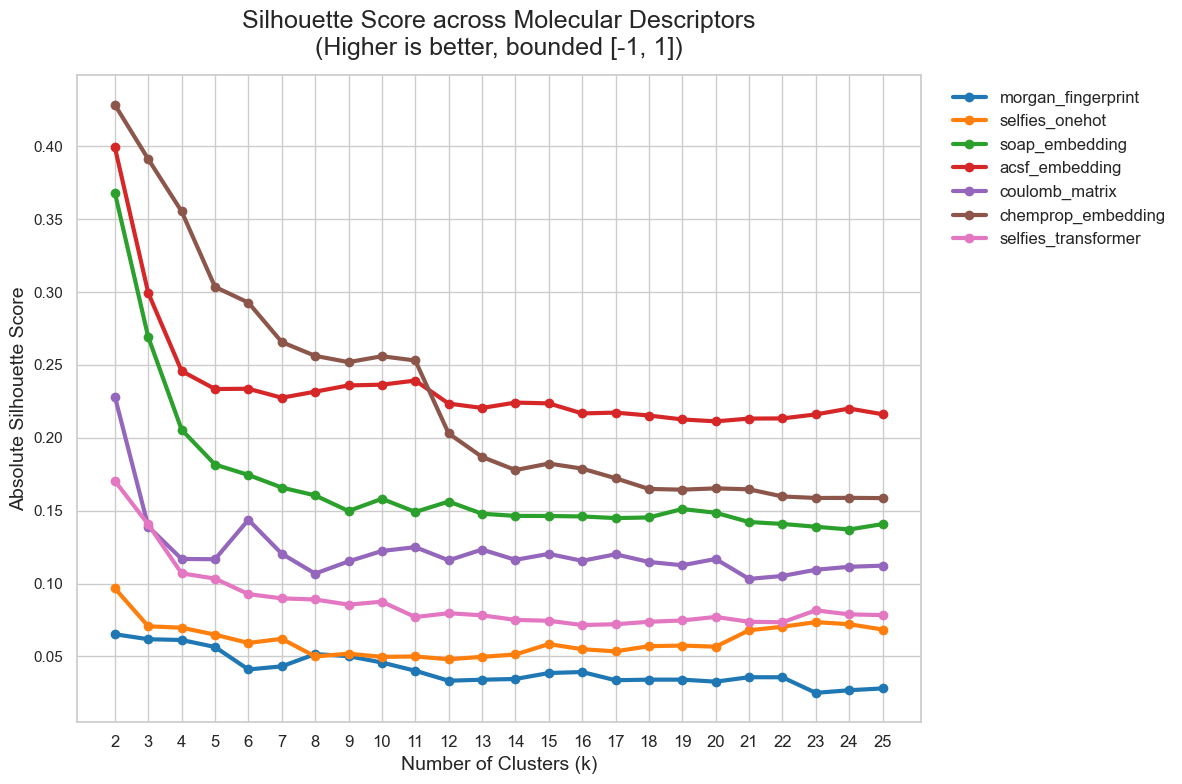

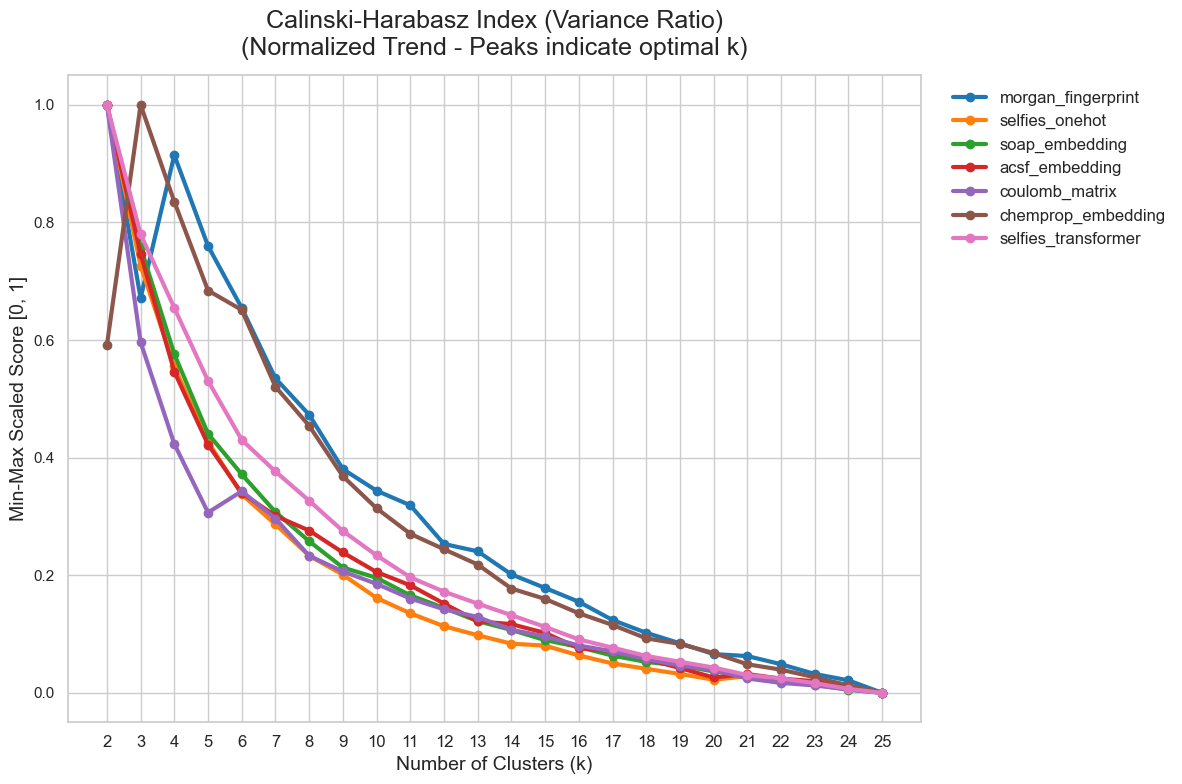

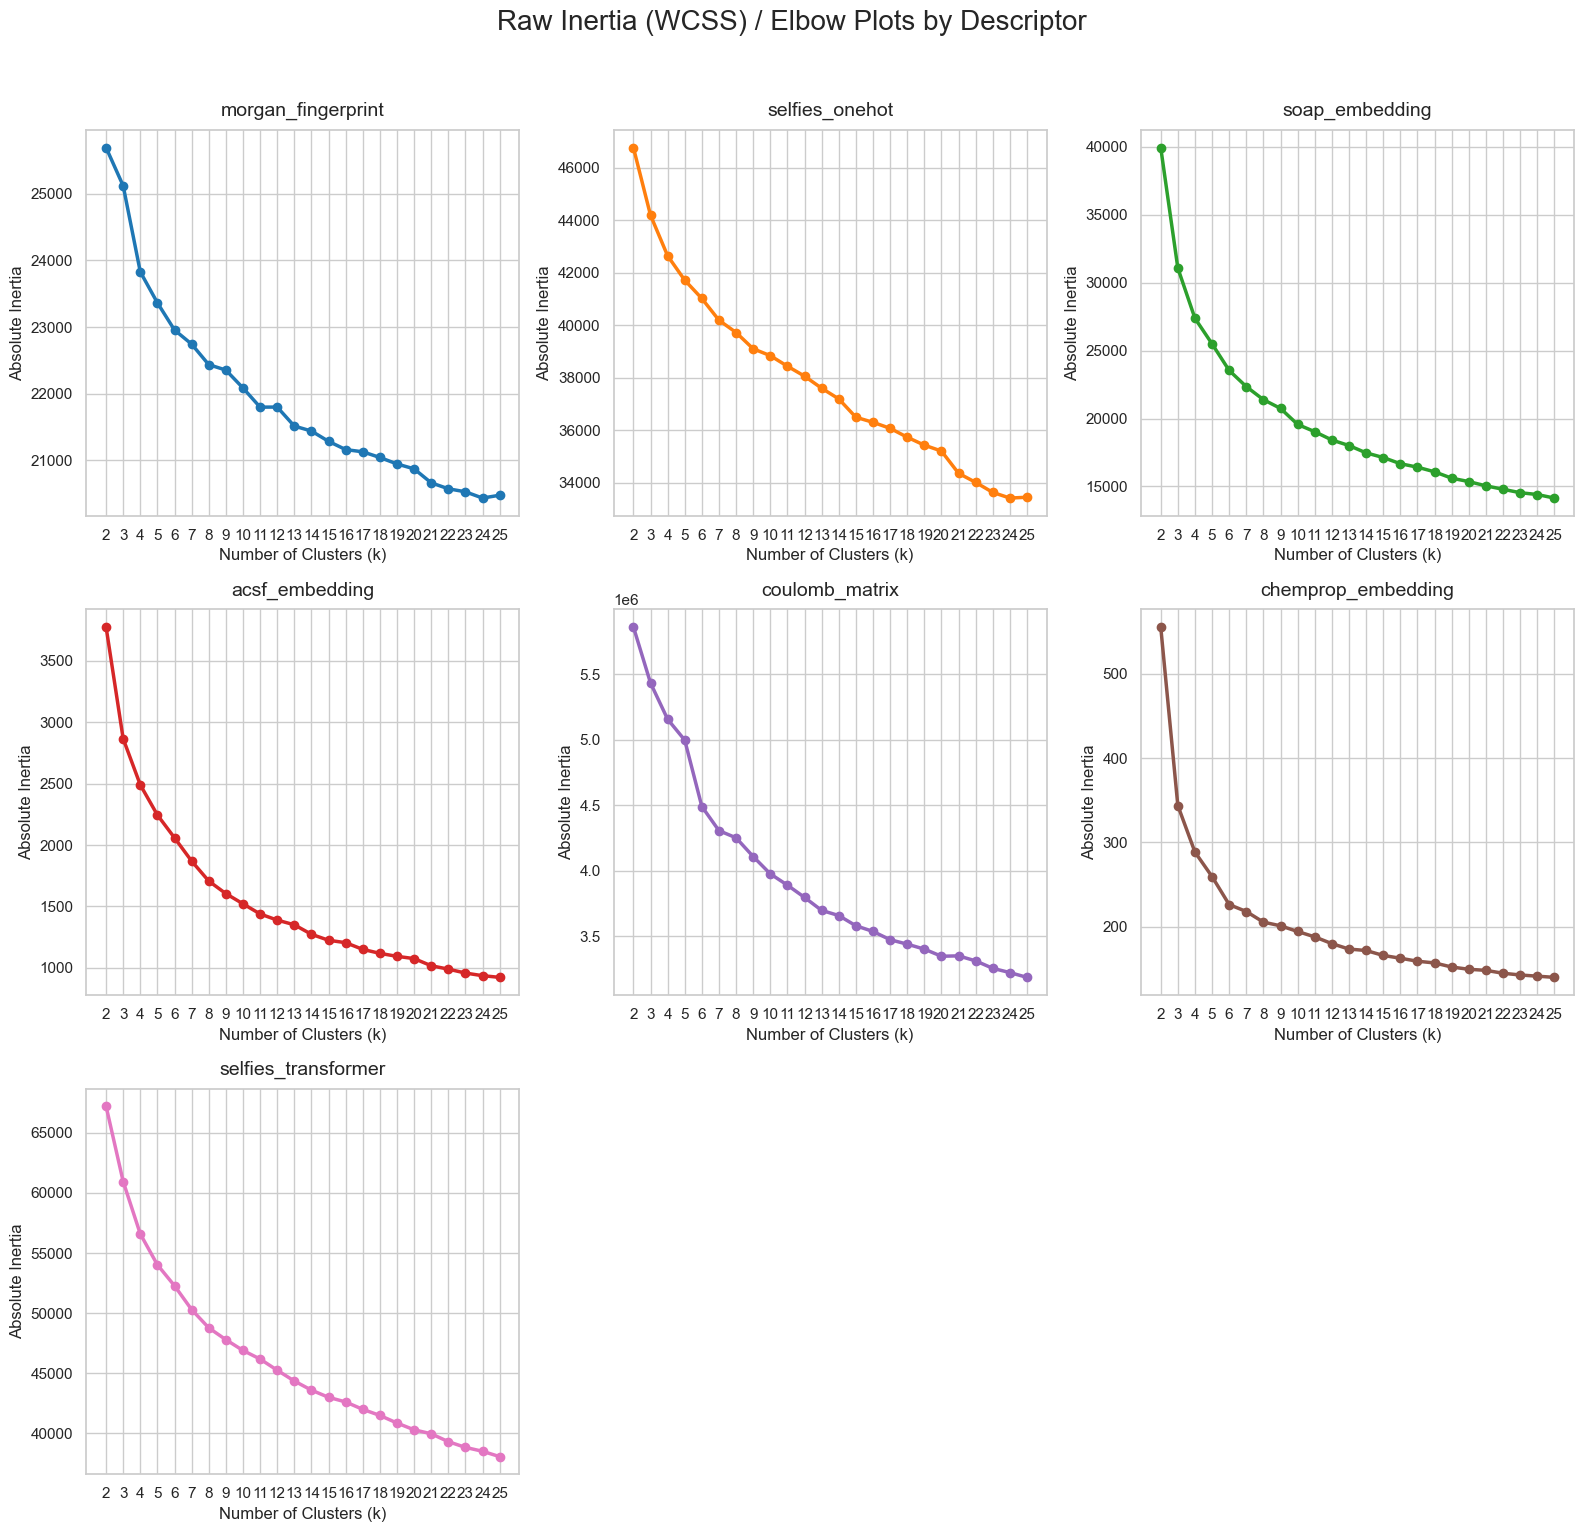

In [17]:
results = get_correct_number_of_clusters(qm9.df)

# number of clusters for each:
- morgan: 8/10
- onehot: 7/8
- soap: 7
- acsf: 7
- coulomb: 6
- chemprop: 6
- transformer: ?


In [36]:
qm9.df

mol_id,smiles,canonical_smiles,selfies,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,morgan_fingerprint,selfies_onehot,soap_embedding,acsf_embedding,coulomb_matrix,chemprop_embedding,selfies_transformer
str,str,str,str,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[i8],list[i64],list[f64],list[f64],list[f64],list[f64],list[f64]
"""qm9_0""","""[H]C([H])([H])[H]""","""[H]C([H])([H])[H]""","""[H][C][Branch1][C][H][Branch1]…",5,"""Acyclic""",16,0,0,1,0,0,0,1.0,0,0,1,0,0,1,2,9,0,0,0,0,0,0,0,0,0,0,0,0.0,13.21,-10.549854,3.186453,13.736308,35.364101,1.217682,-1101.487793,-1101.40979,-1101.384033,-1102.022949,6.469,-17.172182,-17.286823,-17.389656,-16.151918,157.711807,157.709976,157.706985,"[0, 0, … 0]","[0, 0, … 1]","[0.184413, 0.478464, … 0.0]","[2.650031, 1.765813, … 0.0]","[36.858105, 5.493502, … 0.0]","[0.004314, 0.112161, … 0.0]","[0.85723, 0.67413, … -0.194341]"
"""qm9_1""","""[H]N([H])[H]""","""[H]N([H])[H]""","""[H][N][Branch1][C][H][H]""",4,"""Acyclic""",17,0,35,1,0,0,0,0.0,1,1,1,0,0,0,2,6,0,0,0,0,0,0,0,0,0,0,1,1.6256,9.46,-6.993326,2.255824,9.249149,26.1563,0.934929,-1538.147705,-1538.069824,-1538.044189,-1538.666748,6.316,-12.005855,-12.082129,-12.159273,-11.246005,293.609741,293.541107,191.393967,"[0, 0, … 0]","[0, 0, … 1]","[0.170095, 0.427155, … 0.0]","[1.94162, 1.53645, … 0.0]","[53.358707, 6.869482, … 0.0]","[0.0, 0.024966, … 0.0]","[0.835795, 0.565978, … 0.348474]"
"""qm9_2""","""[H]O[H]""","""[H]O[H]""","""[H][O][H]""",3,"""Acyclic""",18,0,31,1,0,0,0,0.0,0,0,0,0,0,0,2,3,0,0,0,0,0,0,0,0,0,0,1,1.8511,6.31,-7.967494,1.869422,9.836916,19.0002,0.581643,-2079.077881,-2079.000732,-2078.975098,-2079.558105,6.002,-9.240362,-9.278811,-9.330214,-8.733849,799.588135,437.90387,282.945465,"[0, 0, … 0]","[0, 0, … 1]","[0.150713, 0.392522, … 0.0]","[1.190363, 1.052614, … 0.0]","[73.516695, 8.255933, … 0.0]","[0.006422, 0.0, … 0.0]","[1.035763, 0.256207, … 0.323382]"
"""qm9_3""","""[H]C#C[H]""","""[H]C#C[H]""","""[H][C][#C][H]""",4,"""Acyclic""",26,0,0,2,0,0,0,0.0,0,0,0,2,0,0,3,4,0,0,0,0,0,0,0,0,0,0,0,0.0,16.280001,-7.741639,1.376896,9.118535,59.524799,0.730381,-2103.669434,-2103.590576,-2103.564697,-2104.186523,8.574,-16.716963,-16.792231,-16.869347,-15.862634,0.0,35.610035,35.610035,"[0, 0, … 0]","[0, 0, … 1]","[0.116808, 0.322429, … 0.0]","[1.012563, 0.530161, … 0.0]","[36.858105, 29.992443, … 0.0]","[0.088386, 0.0, … 0.020061]","[1.47265, 0.608035, … 0.116478]"
"""qm9_4""","""[H]C#N""","""[H]C#N""","""[H][C][#N]""",3,"""Acyclic""",27,0,23,2,0,0,0,0.0,0,1,0,1,0,0,2,3,0,0,0,0,0,0,0,0,0,0,1,2.8937,12.99,-9.806983,0.519737,10.329442,48.747601,0.451736,-2541.866943,-2541.79834,-2541.772705,-2542.393555,6.278,-13.088188,-13.13529,-13.186666,-12.520096,0.0,44.593884,44.593884,"[0, 0, … 0]","[0, 0, … 1]","[0.077737, 0.214865, … 0.0]","[0.540542, 0.358622, … 0.0]","[53.358707, 36.206892, … 0.0]","[0.041949, 0.0, … 0.02049]","[0.546197, 0.145142, … -0.164353]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""qm9_2230""","""[H]C(=O)N([H])C1([H])C([H])([H…","""[H]C(=O)N([H])C1([H])C([H])([H…","""[H][C][=Branch1][C][=O][N][Bra…",14,"""Aliphatic Ring""",101,0,38,7,1,0,1,0.75,1,2,5,0,1,3,5,28,0,0,0,0,1,0,0,0,1,0,3,2.7698,55.389999,-6.976999,0.536064,7.513064,858.688416,3.099241,-9842.638672,-9842.450195,-9842.423828,-9843.509766,23.656,-57.369255,-57.719849,-58.053978,-53.404961,7.7071,1.43215,1.39873,"[0, 0, … 0]","[0, 0, … 1]",

In [43]:
def cluster_and_export(df, descriptor_name, num_clusters=2):

    X = np.stack(df[descriptor_name].to_list())
    
    structures, valid_indices = get_structures(df)
    
    df = df[valid_indices]
    X = X[valid_indices]

    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(X)
    
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
    X_tsne = tsne.fit_transform(X)
    
    if "mol_id" in df.columns:
        ari_score = adjusted_rand_score(df["mol_id"].to_list(), cluster_labels)
        print(f"Clustering Performance (ARI): {ari_score:.4f}")
        
    df_results = df.with_columns([
        pl.Series("cluster", cluster_labels),
        pl.Series("tsne_1", X_tsne[:, 0]),
        pl.Series("tsne_2", X_tsne[:, 1])
    ])
    
    print("\nCluster Composition Summary:")
    summary_table = (
        df_results.group_by("cluster")
        .agg([
            pl.col("mol_id").n_unique().alias("unique_mols") if "mol_id" in df.columns else pl.len().alias("count"),
            pl.col("canonical_smiles").first().alias("representative_smiles") if "canonical_smiles" in df.columns else pl.lit("").alias("smiles"),
            pl.len().alias("total_samples")
        ])
        .sort("cluster")
    )
    display(summary_table)

    fr_cols = [col for col in df.columns if col.startswith("fr_")]
    fr_data = {col: df[col].to_list() for col in fr_cols}
    
    functional_groups_list = []
    for i in range(len(df)):
        groups = [col.replace("fr_", "") for col in fr_cols if fr_data[col][i] == 1]
        functional_groups_list.append(", ".join(groups) if groups else "None")

    properties = {
        "t-SNE 1": X_tsne[:, 0].tolist(),
        "t-SNE 2": X_tsne[:, 1].tolist(),
        "Cluster": cluster_labels.tolist(),
        "Functional Groups": functional_groups_list
    }

    meta_cols = ["mol_id", "canonical_smiles", "structure_class"]
    for col in meta_cols:
        if col in df.columns:
            properties[col] = df[col].to_list()

    output_path = f"report/qm9/figures/grassmann/chemiscope_{descriptor_name}_k{num_clusters}.json.gz"

    chemiscope.write_input(
        output_path,
        structures=structures,
        properties=properties,
    )
    
    print(f"\nChemiscope file successfully saved to: {output_path}\n")
    return output_path, summary_table, df_results

In [65]:
# morgan_fingerprint	selfies_onehot	soap_embedding	acsf_embedding	coulomb_matrix	chemprop_embedding	selfies_transformer
# morgan: 3/8/10  - onehot: 7/8 - soap: 7 - acsf: 7 - coulomb: 6 - chemprop: 6
output_path, summary, results_df = cluster_and_export(
    df=qm9.df, 
    descriptor_name="selfies_onehot", 
    num_clusters=3
)

Skipping qm9_686: Failed to generate 3D conformer.
Clustering Performance (ARI): 0.0000

Cluster Composition Summary:


cluster,unique_mols,representative_smiles,total_samples
i32,u32,str,u32
0,838,"""[H]C([H])([H])C([H])(C([H])([H…",838
1,564,"""[H]C([H])([H])C(C([H])([H])[H]…",564
2,597,"""[H]C([H])([H])[H]""",597



Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_selfies_onehot_k3.json.gz



In [66]:
chemiscope.show_input(output_path)

<ChemiscopeWidget(meta={'name': 'chemiscope_selfies_onehot_k3'}, structures=[{'size': 5, 'data': 'structure-0'…